# ESM2-650M Fine-Tuning with LoRA for Protein Function Retrieval

**Project:** Benchmarking Protein Function Retrieval — BLAST vs k-mer vs ESM2  
**Notebook:** Method 3b — Fine-tuned ESM2 with LoRA (contrastive learning)  
**Hardware:** A100 40GB recommended (also works on A100 80GB)

---

## Why not Unsloth?
Unsloth is optimised exclusively for **decoder-only** LLMs (Llama, Mistral, Gemma).  
ESM2 is an **encoder-only** model — no causal attention, no autoregressive head.  
We use HuggingFace **PEFT** instead, which fully supports encoder LoRA.

## What this notebook does
1. Loads your precomputed embeddings + qrels from the fixed notebook (no re-embedding)
2. Mines hard negatives from ESM2-650M's current retrieval mistakes
3. Fine-tunes ESM2-650M with LoRA using **MultipleNegativesRankingLoss** (contrastive)
4. Re-embeds corpus + queries with the fine-tuned model
5. Evaluates with pytrec_eval (same as fixed notebook) and compares before vs after

## Expected outcome
Baseline ESM2-650M middle-layer MAP@5:  
- Arch Retrieval: ~0.314  
- Euk Retrieval:  ~0.358  

Expected improvement after fine-tuning: +3 to +8 MAP@5 points

## Section 1: Environment Check

In [ ]:
import subprocess, sys

gpu = subprocess.run(
    ['nvidia-smi', '--query-gpu=name,memory.total,memory.free', '--format=csv,noheader'],
    capture_output=True, text=True
)
print('GPU:', gpu.stdout.strip() if gpu.returncode == 0 else 'NOT DETECTED')

import torch
print(f'PyTorch : {torch.__version__}')
print(f'CUDA    : {torch.cuda.is_available()}')
if torch.cuda.is_available():
    gb = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f'VRAM    : {gb:.1f} GB')
    if gb < 30:
        print('WARNING: < 30 GB VRAM. Use batch_size=4 and gradient_checkpointing=True.')

GPU: NVIDIA A100-SXM4-80GB, 81920 MiB, 81153 MiB
PyTorch : 2.10.0+cu128
CUDA    : True
VRAM    : 85.1 GB


## Section 2: Install Dependencies

In [ ]:
%pip install -q peft transformers accelerate datasets dgeb \
               sentence-transformers pytrec-eval-terrier \
               scikit-learn pandas matplotlib tqdm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.4/296.4 kB 9.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 304.8/304.8 kB 26.1 MB/s eta 0:00:00


In [ ]:
%pip install -q peft transformers accelerate datasets dgeb \
               sentence-transformers pytrec-eval-terrier \
               scikit-learn pandas matplotlib tqdm \
               "torchao>=0.16.0" # <-- Added this to fix the PEFT import error

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 75.8 MB/s eta 0:00:00


In [ ]:
import os, json, time, pickle, warnings, random
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from collections import defaultdict

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from transformers import AutoTokenizer, AutoModel, get_linear_schedule_with_warmup
from peft import LoraConfig, get_peft_model, TaskType, PeftModel

import pytrec_eval

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
SEED   = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
print(f'Device: {DEVICE}')

# ── Checkpoint directories ──────────────────────────────────────────────────
try:
    from google.colab import drive
    drive.mount('/content/drive')
    BASE_DIR    = '/content/drive/MyDrive/esm2_checkpoints_690U'
    FINETUNE_DIR = '/content/drive/MyDrive/esm2_finetune_690U'
except ImportError:
    BASE_DIR    = '/content/esm2_checkpoints'
    FINETUNE_DIR = '/content/esm2_finetune'

os.makedirs(FINETUNE_DIR, exist_ok=True)
print(f'Base checkpoint dir : {BASE_DIR}')
print(f'Fine-tune output dir: {FINETUNE_DIR}')

Device: cuda
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Base checkpoint dir : /content/drive/MyDrive/esm2_checkpoints_690U
Fine-tune output dir: /content/drive/MyDrive/esm2_finetune_690U


## Section 3: Load Datasets and Precomputed Embeddings

We reload qrels and sequences fresh (fast), then load the precomputed ESM2-650M  
embeddings from your existing checkpoints — no re-embedding needed for baseline.

In [ ]:
from dgeb.tasks import ArchRetrieval, EukRetrieval

def load_dgeb_task(task_class, task_name):
    """Load queries, corpus, qrels. All stored pairs treated as relevant (fuzz_ratio=1)."""
    print(f'Loading {task_name} ...')
    task = task_class()
    meta = task.metadata
    data_ds  = meta.datasets[0].load()
    qrels_ds = meta.datasets[1].load()

    corpus  = {row['Entry']: row['Sequence'] for row in data_ds['train']}
    queries = {row['Entry']: row['Sequence'] for row in data_ds['test']}

    qrels = defaultdict(dict)
    for split in qrels_ds:
        for row in qrels_ds[split]:
            qrels[str(row['query_id'])][str(row['corpus_id'])] = 1

    print(f'  Queries: {len(queries):,}  Corpus: {len(corpus):,}  '
          f'Relevant pairs: {sum(len(v) for v in qrels.values()):,}')
    return queries, corpus, dict(qrels)


arch_queries, arch_corpus, arch_qrels = load_dgeb_task(ArchRetrieval, 'Arch Retrieval')
euk_queries,  euk_corpus,  euk_qrels  = load_dgeb_task(EukRetrieval,  'Euk Retrieval')

Loading Arch Retrieval ...
  Queries: 2,343  Corpus: 9,229  Relevant pairs: 163,612
Loading Euk Retrieval ...
  Queries: 311  Corpus: 3,202  Relevant pairs: 29,377


In [ ]:
def load_checkpoint(size, task, split):
    """Load precomputed ESM2 embeddings from the fixed notebook's checkpoints."""
    path = os.path.join(BASE_DIR, f'emb_{size}_{task}_{split}.pkl')
    if not os.path.exists(path):
        raise FileNotFoundError(
            f'Checkpoint not found: {path}\n'
            f'Run method3_esm2_fixed.ipynb first to generate embeddings.'
        )
    with open(path, 'rb') as f:
        data = pickle.load(f)
    print(f'  Loaded {path}  shape={data["middle"].shape}')
    return data


print('Loading precomputed ESM2-650M embeddings (baseline)...')
arch_q_emb   = load_checkpoint('650M', 'arch', 'queries')
arch_c_emb   = load_checkpoint('650M', 'arch', 'corpus')
euk_q_emb    = load_checkpoint('650M', 'euk',  'queries')
euk_c_emb    = load_checkpoint('650M', 'euk',  'corpus')

# Middle layer is the best-performing layer from the fixed notebook
LAYER = 'middle'
print(f'\nUsing layer: {LAYER}')

Loading precomputed ESM2-650M embeddings (baseline)...
  Loaded /content/drive/MyDrive/esm2_checkpoints_690U/emb_650M_arch_queries.pkl  shape=(2343, 1280)
  Loaded /content/drive/MyDrive/esm2_checkpoints_690U/emb_650M_arch_corpus.pkl  shape=(9229, 1280)
  Loaded /content/drive/MyDrive/esm2_checkpoints_690U/emb_650M_euk_queries.pkl  shape=(311, 1280)
  Loaded /content/drive/MyDrive/esm2_checkpoints_690U/emb_650M_euk_corpus.pkl  shape=(3202, 1280)

Using layer: middle


## Section 4: Baseline Evaluation (pytrec_eval)

Confirm the baseline matches what the fixed notebook reported before fine-tuning.

In [ ]:
def cosine_retrieve(q_embs, c_embs, corpus_ids, top_k=5, chunk_size=256):
    """L2-normalised cosine similarity retrieval. Returns list of ranked corpus_id lists."""
    q_norm = q_embs / (np.linalg.norm(q_embs, axis=1, keepdims=True) + 1e-10)
    c_norm = c_embs / (np.linalg.norm(c_embs, axis=1, keepdims=True) + 1e-10)
    cids   = np.array(corpus_ids)
    results = []
    for start in range(0, len(q_norm), chunk_size):
        chunk = q_norm[start:start + chunk_size]
        sims  = chunk @ c_norm.T
        top   = np.argpartition(sims, -top_k, axis=1)[:, -top_k:]
        for i, idx in enumerate(top):
            s = sims[i, idx]
            results.append(cids[idx[np.argsort(-s)]].tolist())
    return results


def evaluate_pytrec(query_ids, retrieved_list, qrels, k_values=(5,)):
    """Exact DGEB evaluation using pytrec_eval (map_cut)."""
    results = {
        qid: {cid: 1.0 / (r + 1) for r, cid in enumerate(ret)}
        for qid, ret in zip(query_ids, retrieved_list)
    }
    ks = list(k_values)
    ev = pytrec_eval.RelevanceEvaluator(
        qrels,
        {f'map_cut.{k}'  for k in ks} |
        {f'ndcg_cut.{k}' for k in ks} |
        {f'recall.{k}'   for k in ks}
    )
    scores = ev.evaluate(results)
    out = {}
    for k in ks:
        out[f'MAP@{k}']    = round(np.mean([scores[q][f'map_cut_{k}']  for q in scores]), 5)
        out[f'nDCG@{k}']   = round(np.mean([scores[q][f'ndcg_cut_{k}'] for q in scores]), 5)
        out[f'Recall@{k}'] = round(np.mean([scores[q][f'recall_{k}']   for q in scores]), 5)
    out['n_queries'] = len(scores)
    return out


print('=== BASELINE (ESM2-650M middle layer, no fine-tuning) ===')

arch_retrieved_base = cosine_retrieve(
    arch_q_emb[LAYER], arch_c_emb[LAYER], arch_c_emb['ids'], top_k=5
)
arch_base = evaluate_pytrec(arch_q_emb['ids'], arch_retrieved_base, arch_qrels)
print(f'Arch: {arch_base}')

euk_retrieved_base = cosine_retrieve(
    euk_q_emb[LAYER], euk_c_emb[LAYER], euk_c_emb['ids'], top_k=5
)
euk_base = evaluate_pytrec(euk_q_emb['ids'], euk_retrieved_base, euk_qrels)
print(f'Euk:  {euk_base}')

print('\n(Expected: Arch MAP@5 ≈ 0.314, Euk MAP@5 ≈ 0.358)')

=== BASELINE (ESM2-650M middle layer, no fine-tuning) ===
Arch: {'MAP@5': np.float64(0.31398), 'nDCG@5': np.float64(0.93684), 'Recall@5': np.float64(0.32), 'n_queries': 2343}
Euk:  {'MAP@5': np.float64(0.35844), 'nDCG@5': np.float64(0.93417), 'Recall@5': np.float64(0.36681), 'n_queries': 311}

(Expected: Arch MAP@5 ≈ 0.314, Euk MAP@5 ≈ 0.358)


## Section 5: Build Training Data

### Strategy
- **Positives**: all qrels pairs (query → relevant corpus protein)
- **Hard negatives**: corpus proteins that ESM2 retrieves in top-50 but are NOT in qrels  
  These are the model's current mistakes — exactly what fine-tuning should fix
- **Train/val split**: 85% / 15% of queries (by query ID, not pairs)

### Loss: MultipleNegativesRankingLoss
For each (anchor, positive) pair in a batch, all other positives in the batch act as  
in-batch negatives. Combined with explicit hard negatives, this is the standard  
approach for contrastive embedding fine-tuning.

In [ ]:
from sklearn.model_selection import train_test_split

# ── 1. Mine hard negatives from top-50 retrieval ─────────────────────────────
print('Mining hard negatives from ESM2-650M top-50 retrieval...')

arch_top50 = cosine_retrieve(
    arch_q_emb[LAYER], arch_c_emb[LAYER], arch_c_emb['ids'], top_k=50
)

def mine_hard_negatives(query_ids, top_k_results, qrels, n_hard=5):
    """Collect up to n_hard hard negatives per query."""
    hard_negs = {}
    for qid, retrieved in zip(query_ids, top_k_results):
        positives = set(qrels.get(qid, {}).keys())
        hn = [cid for cid in retrieved if cid not in positives]
        if hn:
            hard_negs[qid] = hn[:n_hard]
    n_total = sum(len(v) for v in hard_negs.values())
    print(f'  Queries with hard negatives: {len(hard_negs):,}')
    print(f'  Total hard negatives mined : {n_total:,}')
    return hard_negs

arch_hard_negs = mine_hard_negatives(arch_q_emb['ids'], arch_top50, arch_qrels, n_hard=5)


# ── 2. Train / val split on query IDs ────────────────────────────────────────
all_qids = list(arch_qrels.keys())
train_qids, val_qids = train_test_split(all_qids, test_size=0.15, random_state=SEED)
print(f'\nTraining queries  : {len(train_qids):,}')
print(f'Validation queries: {len(val_qids):,}')


# ── 3. Build (anchor, positive, hard_negative) triplets ──────────────────────
def build_triplets(qids, queries, corpus, qrels, hard_negs, max_pos_per_query=10):
    """
    Build training triplets.
    Cap positives per query to avoid queries with 500 positives dominating.
    Each triplet: (anchor_seq, positive_seq, hard_neg_seq)
    """
    triplets = []
    skipped  = 0
    for qid in qids:
        if qid not in queries or qid not in qrels:
            skipped += 1
            continue
        q_seq    = queries[qid]
        pos_ids  = list(qrels[qid].keys())
        random.shuffle(pos_ids)
        pos_ids  = pos_ids[:max_pos_per_query]   # cap to avoid imbalance
        hn_ids   = hard_negs.get(qid, [])

        if not hn_ids:
            # Fall back to a random corpus protein as negative
            hn_ids = random.sample(list(corpus.keys()), 3)

        for pos_id in pos_ids:
            pos_seq = corpus.get(pos_id)
            if not pos_seq:
                continue
            neg_id  = random.choice(hn_ids)
            neg_seq = corpus.get(neg_id)
            if not neg_seq:
                continue
            triplets.append((q_seq, pos_seq, neg_seq))

    print(f'  Triplets built: {len(triplets):,}  (skipped {skipped} queries with missing data)')
    return triplets


print('\nBuilding training triplets...')
train_triplets = build_triplets(
    train_qids, arch_queries, arch_corpus, arch_qrels, arch_hard_negs,
    max_pos_per_query=10
)

print('Building validation triplets...')
val_triplets = build_triplets(
    val_qids, arch_queries, arch_corpus, arch_qrels, arch_hard_negs,
    max_pos_per_query=5
)

print(f'\nFinal counts — Train: {len(train_triplets):,}  Val: {len(val_triplets):,}')

Mining hard negatives from ESM2-650M top-50 retrieval...
  Queries with hard negatives: 1,842
  Total hard negatives mined : 9,018

Training queries  : 1,991
Validation queries: 352

Building training triplets...
  Triplets built: 16,870  (skipped 0 queries with missing data)
Building validation triplets...
  Triplets built: 1,602  (skipped 0 queries with missing data)

Final counts — Train: 16,870  Val: 1,602


In [ ]:
class TripletProteinDataset(Dataset):
    """Dataset of (anchor, positive, hard_negative) sequence triplets."""
    def __init__(self, triplets):
        self.triplets = triplets

    def __len__(self):
        return len(self.triplets)

    def __getitem__(self, idx):
        anchor, positive, negative = self.triplets[idx]
        return {'anchor': anchor, 'positive': positive, 'negative': negative}


def collate_triplets(batch, tokenizer, max_length=512):
    """
    Tokenize all three sequences in a batch.
    max_length=512 covers >95% of UniProt sequences and halves memory vs 1024.
    """
    def tok(seqs):
        return tokenizer(
            seqs, return_tensors='pt', padding=True,
            truncation=True, max_length=max_length
        )
    anchors   = tok([b['anchor']   for b in batch])
    positives = tok([b['positive'] for b in batch])
    negatives = tok([b['negative'] for b in batch])
    return anchors, positives, negatives


print('Dataset classes defined.')

Dataset classes defined.


## Section 6: LoRA Configuration and Model Setup

### LoRA targets for ESM2
ESM2's attention layer names: `query`, `key`, `value`, `dense`  
We target `query` and `value` — standard practice, same as in NLP encoder fine-tuning.  
This adds ~2.4M trainable parameters to ESM2-650M's 650M frozen parameters (~0.37%).

### Why not QLoRA here?
QLoRA (4-bit quantization) is designed for decoder LLMs with `bitsandbytes`.  
ESM2's encoder attention is not compatible with `bitsandbytes` int4 quantization.  
With an A100 and LoRA in bfloat16, VRAM usage is ~6 GB — well within budget.

In [ ]:
MODEL_ID     = 'facebook/esm2_t33_650M_UR50D'
MIDDLE_LAYER = 17   # optimal layer from fixed notebook
MAX_LENGTH   = 512  # covers >95% of UniProt seqs; halves VRAM vs 1024

print(f'Loading tokenizer and base model: {MODEL_ID}')
tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)

base_model = AutoModel.from_pretrained(
    MODEL_ID,
    output_hidden_states=True,
    torch_dtype=torch.bfloat16,
).to(DEVICE)

# ── LoRA config ──────────────────────────────────────────────────────────────
# ESM2 uses RobertaLayer-style attention with these projection names.
# Confirmed by: [n for n, _ in base_model.named_modules() if 'query' in n][:3]
lora_config = LoraConfig(
    task_type=TaskType.FEATURE_EXTRACTION,  # encoder, no LM head
    r=16,                    # rank — controls capacity. 8 is minimal, 32 is rich
    lora_alpha=32,           # scaling factor = lora_alpha / r = 2.0
    target_modules=['query', 'value'],  # attention projections
    lora_dropout=0.1,
    bias='none',             # don't train biases (saves memory)
    inference_mode=False,
)

model = get_peft_model(base_model, lora_config)
model.print_trainable_parameters()
# Expected: ~2.4M trainable / 652M total (~0.37%)

Loading tokenizer and base model: facebook/esm2_t33_650M_UR50D


Loading weights:   0%|          | 0/566 [00:00<?, ?it/s]

EsmModel LOAD REPORT from: facebook/esm2_t33_650M_UR50D
Key                         | Status     | 
----------------------------+------------+-
esm.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
pooler.dense.weight         | MISSING    | 
pooler.dense.bias           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


trainable params: 2,703,360 || all params: 653,744,021 || trainable%: 0.4135


## Section 7: Training Loop

### Loss: Triplet Margin Loss with cosine distance
```
L = max(0,  d(anchor, positive) - d(anchor, negative) + margin)
```
where `d` is cosine distance (1 - cosine_similarity).  
Margin = 0.3 is standard for biological sequence embedding tasks.

In [ ]:
# ── Hyperparameters ───────────────────────────────────────────────────────────
# A100 40GB: batch_size=16 is safe with max_length=512 and bfloat16
# A100 80GB: can push to batch_size=32
BATCH_SIZE    = 16
NUM_EPOCHS    = 3       # 3 epochs is usually enough for contrastive fine-tuning
LR            = 2e-4    # standard LoRA learning rate
WARMUP_RATIO  = 0.1     # 10% of steps for warmup
MARGIN        = 0.3     # triplet margin
GRAD_CLIP     = 1.0
EVAL_EVERY    = 200     # evaluate on val set every N steps
SAVE_BEST     = True    # save checkpoint when val MAP@5 improves

print(f'Batch size : {BATCH_SIZE}')
print(f'Epochs     : {NUM_EPOCHS}')
print(f'LR         : {LR}')
print(f'Margin     : {MARGIN}')
steps_per_epoch = len(train_triplets) // BATCH_SIZE
total_steps     = steps_per_epoch * NUM_EPOCHS
warmup_steps    = int(total_steps * WARMUP_RATIO)
print(f'Total steps: {total_steps}  Warmup: {warmup_steps}')

Batch size : 16
Epochs     : 3
LR         : 0.0002
Margin     : 0.3
Total steps: 3162  Warmup: 316


In [ ]:
def mean_pool_valid(hidden_states, input_ids, cls_id, eos_id, pad_id):
    """
    Mean-pool over real amino acid tokens only.
    Excludes <cls>, <eos>, <pad> — identical to the fixed notebook's logic.
    Returns float32 tensor (B, H).
    """
    mask = (
        (input_ids != cls_id) &
        (input_ids != eos_id) &
        (input_ids != pad_id)
    ).unsqueeze(-1).float()
    h = hidden_states.float()
    return (h * mask).sum(1) / mask.sum(1).clamp(min=1e-9)


def encode_batch(model, enc, middle_layer, tokenizer):
    """
    Forward pass → middle-layer mean-pooled embedding.
    Returns L2-normalised float32 tensor (B, H).
    """
    enc = {k: v.to(DEVICE) for k, v in enc.items()}

    # FIX: Explicitly request hidden states from the PEFT model
    out = model(**enc, output_hidden_states=True)

    h   = out.hidden_states[middle_layer]  # (B, L, H)
    emb = mean_pool_valid(
        h, enc['input_ids'],
        tokenizer.cls_token_id,
        tokenizer.eos_token_id,
        tokenizer.pad_token_id,
    )  # (B, H) float32
    return F.normalize(emb, dim=-1)  # L2-normalise


def triplet_loss_cosine(anchor, positive, negative, margin=0.3):
    """
    Triplet margin loss with cosine distance.
    All inputs must be L2-normalised — cosine sim = dot product.
    d_pos = 1 - sim(a, p),  d_neg = 1 - sim(a, n)
    L = mean(max(0, d_pos - d_neg + margin))
    """
    d_pos = 1.0 - (anchor * positive).sum(dim=-1)  # cosine distance
    d_neg = 1.0 - (anchor * negative).sum(dim=-1)
    loss  = F.relu(d_pos - d_neg + margin)
    return loss.mean()


print('Loss and encoding functions defined.')

Loss and encoding functions defined.


In [ ]:
# ── DataLoaders ───────────────────────────────────────────────────────────────
from functools import partial

collate_fn = partial(collate_triplets, tokenizer=tokenizer, max_length=MAX_LENGTH)

train_loader = DataLoader(
    TripletProteinDataset(train_triplets),
    batch_size=BATCH_SIZE, shuffle=True,
    collate_fn=collate_fn, num_workers=2, pin_memory=True
)
val_loader = DataLoader(
    TripletProteinDataset(val_triplets),
    batch_size=BATCH_SIZE, shuffle=False,
    collate_fn=collate_fn, num_workers=2, pin_memory=True
)

# ── Optimizer + scheduler ─────────────────────────────────────────────────────
optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LR, weight_decay=0.01
)
scheduler = get_linear_schedule_with_warmup(
    optimizer, num_warmup_steps=warmup_steps,
    num_training_steps=total_steps
)

print(f'Train batches per epoch: {len(train_loader)}')
print(f'Val batches: {len(val_loader)}')

Train batches per epoch: 1055
Val batches: 101


In [ ]:
# ── Quick validation loss (proxy metric during training) ──────────────────────
@torch.inference_mode()
def compute_val_loss(model, val_loader, n_batches=30):
    """Estimate validation loss on first n_batches to keep eval fast."""
    model.eval()
    losses = []
    for i, (anc_enc, pos_enc, neg_enc) in enumerate(val_loader):
        if i >= n_batches:
            break
        a = encode_batch(model, anc_enc, MIDDLE_LAYER, tokenizer)
        p = encode_batch(model, pos_enc, MIDDLE_LAYER, tokenizer)
        n = encode_batch(model, neg_enc, MIDDLE_LAYER, tokenizer)
        losses.append(triplet_loss_cosine(a, p, n, MARGIN).item())
    model.train()
    return float(np.mean(losses))


# ── Main training loop ────────────────────────────────────────────────────────
history = {'train_loss': [], 'val_loss': [], 'step': []}
best_val_loss = float('inf')
global_step   = 0

model.train()
print('Starting training...\n')
t0 = time.time()

for epoch in range(NUM_EPOCHS):
    epoch_losses = []
    pbar = tqdm(train_loader, desc=f'Epoch {epoch+1}/{NUM_EPOCHS}', leave=True)

    for anc_enc, pos_enc, neg_enc in pbar:
        optimizer.zero_grad()

        a = encode_batch(model, anc_enc, MIDDLE_LAYER, tokenizer)
        p = encode_batch(model, pos_enc, MIDDLE_LAYER, tokenizer)
        n = encode_batch(model, neg_enc, MIDDLE_LAYER, tokenizer)

        loss = triplet_loss_cosine(a, p, n, MARGIN)
        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            filter(lambda p: p.requires_grad, model.parameters()), GRAD_CLIP
        )
        optimizer.step()
        scheduler.step()

        loss_val = loss.item()
        epoch_losses.append(loss_val)
        global_step += 1
        pbar.set_postfix({'loss': f'{loss_val:.4f}', 'lr': f'{scheduler.get_last_lr()[0]:.2e}'})

        # Periodic validation
        if global_step % EVAL_EVERY == 0:
            vl = compute_val_loss(model, val_loader)
            tl = float(np.mean(epoch_losses[-EVAL_EVERY:]))
            history['step'].append(global_step)
            history['train_loss'].append(tl)
            history['val_loss'].append(vl)
            print(f'  Step {global_step:5d} | train_loss={tl:.4f} | val_loss={vl:.4f}')

            if SAVE_BEST and vl < best_val_loss:
                best_val_loss = vl
                save_path = os.path.join(FINETUNE_DIR, 'best_lora_checkpoint')
                model.save_pretrained(save_path)
                tokenizer.save_pretrained(save_path)
                print(f'  ✓ New best val_loss={vl:.4f} — saved to {save_path}')

    print(f'Epoch {epoch+1} done | avg_train_loss={np.mean(epoch_losses):.4f} | '
          f'elapsed={time.time()-t0:.0f}s')

# Save final checkpoint regardless
final_path = os.path.join(FINETUNE_DIR, 'final_lora_checkpoint')
model.save_pretrained(final_path)
tokenizer.save_pretrained(final_path)
print(f'\nTraining complete. Final checkpoint: {final_path}')

Starting training...



Epoch 1/3:   0%|          | 0/1055 [00:00<?, ?it/s]

  Step   200 | train_loss=0.2231 | val_loss=0.1203
  ✓ New best val_loss=0.1203 — saved to /content/drive/MyDrive/esm2_finetune_690U/best_lora_checkpoint
  Step   400 | train_loss=0.0785 | val_loss=0.0743
  ✓ New best val_loss=0.0743 — saved to /content/drive/MyDrive/esm2_finetune_690U/best_lora_checkpoint
  Step   600 | train_loss=0.0459 | val_loss=0.0656
  ✓ New best val_loss=0.0656 — saved to /content/drive/MyDrive/esm2_finetune_690U/best_lora_checkpoint
  Step   800 | train_loss=0.0429 | val_loss=0.0524
  ✓ New best val_loss=0.0524 — saved to /content/drive/MyDrive/esm2_finetune_690U/best_lora_checkpoint
  Step  1000 | train_loss=0.0378 | val_loss=0.0515
  ✓ New best val_loss=0.0515 — saved to /content/drive/MyDrive/esm2_finetune_690U/best_lora_checkpoint
Epoch 1 done | avg_train_loss=0.0829 | elapsed=801s


Epoch 2/3:   0%|          | 0/1055 [00:00<?, ?it/s]

  Step  1200 | train_loss=0.0294 | val_loss=0.0483
  ✓ New best val_loss=0.0483 — saved to /content/drive/MyDrive/esm2_finetune_690U/best_lora_checkpoint
  Step  1400 | train_loss=0.0266 | val_loss=0.0399
  ✓ New best val_loss=0.0399 — saved to /content/drive/MyDrive/esm2_finetune_690U/best_lora_checkpoint
  Step  1600 | train_loss=0.0210 | val_loss=0.0429
  Step  1800 | train_loss=0.0229 | val_loss=0.0400
  Step  2000 | train_loss=0.0206 | val_loss=0.0358
  ✓ New best val_loss=0.0358 — saved to /content/drive/MyDrive/esm2_finetune_690U/best_lora_checkpoint
Epoch 2 done | avg_train_loss=0.0228 | elapsed=1602s


Epoch 3/3:   0%|          | 0/1055 [00:00<?, ?it/s]

  Step  2200 | train_loss=0.0112 | val_loss=0.0254
  ✓ New best val_loss=0.0254 — saved to /content/drive/MyDrive/esm2_finetune_690U/best_lora_checkpoint
  Step  2400 | train_loss=0.0083 | val_loss=0.0251
  ✓ New best val_loss=0.0251 — saved to /content/drive/MyDrive/esm2_finetune_690U/best_lora_checkpoint
  Step  2600 | train_loss=0.0091 | val_loss=0.0248
  ✓ New best val_loss=0.0248 — saved to /content/drive/MyDrive/esm2_finetune_690U/best_lora_checkpoint
  Step  2800 | train_loss=0.0069 | val_loss=0.0239
  ✓ New best val_loss=0.0239 — saved to /content/drive/MyDrive/esm2_finetune_690U/best_lora_checkpoint
  Step  3000 | train_loss=0.0072 | val_loss=0.0238
  ✓ New best val_loss=0.0238 — saved to /content/drive/MyDrive/esm2_finetune_690U/best_lora_checkpoint
Epoch 3 done | avg_train_loss=0.0082 | elapsed=2404s

Training complete. Final checkpoint: /content/drive/MyDrive/esm2_finetune_690U/final_lora_checkpoint


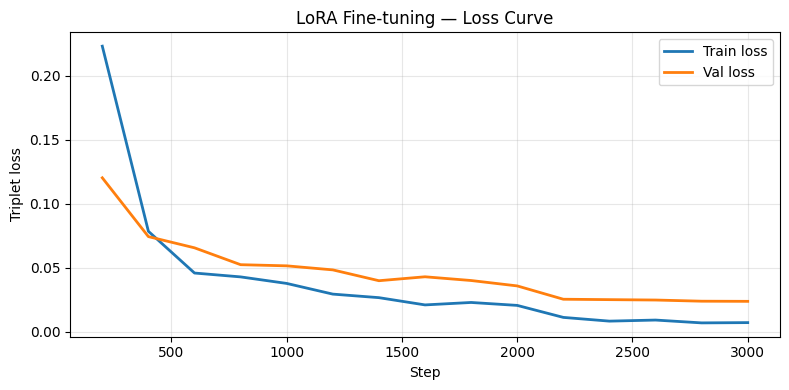

Loss curve saved.


In [ ]:
# ── Training curve ────────────────────────────────────────────────────────────
if history['step']:
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(history['step'], history['train_loss'], label='Train loss', linewidth=2)
    ax.plot(history['step'], history['val_loss'],   label='Val loss',   linewidth=2)
    ax.set_xlabel('Step')
    ax.set_ylabel('Triplet loss')
    ax.set_title('LoRA Fine-tuning — Loss Curve')
    ax.legend()
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(os.path.join(FINETUNE_DIR, 'loss_curve.png'), dpi=150)
    plt.show()
    print('Loss curve saved.')
else:
    print('No eval steps recorded — increase NUM_EPOCHS or decrease EVAL_EVERY.')

## Section 8: Re-embed with Fine-tuned Model

Load the best checkpoint and re-embed all queries and corpus proteins.

In [ ]:
# ── Load best checkpoint ──────────────────────────────────────────────────────
print('Loading best LoRA checkpoint...')
best_ckpt = os.path.join(FINETUNE_DIR, 'best_lora_checkpoint')
if not os.path.exists(best_ckpt):
    best_ckpt = os.path.join(FINETUNE_DIR, 'final_lora_checkpoint')
    print(f'  Best checkpoint not found, using final: {best_ckpt}')
else:
    print(f'  Using best checkpoint: {best_ckpt}')

# Reload base model + merge LoRA weights
base_model_eval = AutoModel.from_pretrained(
    MODEL_ID, output_hidden_states=True, torch_dtype=torch.bfloat16
).to(DEVICE)
ft_model = PeftModel.from_pretrained(base_model_eval, best_ckpt)
ft_model.eval()
print('Fine-tuned model loaded.')

Loading best LoRA checkpoint...
  Using best checkpoint: /content/drive/MyDrive/esm2_finetune_690U/best_lora_checkpoint


Loading weights:   0%|          | 0/566 [00:00<?, ?it/s]

EsmModel LOAD REPORT from: facebook/esm2_t33_650M_UR50D
Key                         | Status     | 
----------------------------+------------+-
esm.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
pooler.dense.weight         | MISSING    | 
pooler.dense.bias           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Fine-tuned model loaded.


In [ ]:
@torch.inference_mode()
def embed_sequences(model, sequences_dict, tokenizer, layer,
                    batch_size=8, max_length=512):
    """
    Embed all sequences in sequences_dict using specified layer.
    Returns {'ids': [...], 'embs': np.ndarray (N, H)}
    """
    ids  = list(sequences_dict.keys())
    seqs = [sequences_dict[i] for i in ids]
    all_embs = []

    for start in tqdm(range(0, len(seqs), batch_size), desc='Embedding'):
        batch_seqs = seqs[start:start + batch_size]
        enc = tokenizer(
            batch_seqs, return_tensors='pt', padding=True,
            truncation=True, max_length=max_length
        ).to(DEVICE)

        # FIX: Explicitly request hidden states here as well!
        out = model(**enc, output_hidden_states=True)

        h   = out.hidden_states[layer]
        emb = mean_pool_valid(
            h, enc['input_ids'],
            tokenizer.cls_token_id,
            tokenizer.eos_token_id,
            tokenizer.pad_token_id,
        ).cpu().numpy().astype(np.float32)
        all_embs.append(emb)

    return {'ids': ids, 'embs': np.vstack(all_embs)}


print('Re-embedding with fine-tuned model (this takes ~10–20 min on A100)...')

print('\nArch queries...')
ft_arch_q = embed_sequences(ft_model, arch_queries, tokenizer, MIDDLE_LAYER)
print('Arch corpus...')
ft_arch_c = embed_sequences(ft_model, arch_corpus, tokenizer, MIDDLE_LAYER)

print('\nEuk queries...')
ft_euk_q  = embed_sequences(ft_model, euk_queries, tokenizer, MIDDLE_LAYER)
print('Euk corpus...')
ft_euk_c  = embed_sequences(ft_model, euk_corpus,  tokenizer, MIDDLE_LAYER)

# Save for reuse
for name, data in [('ft_arch_q', ft_arch_q), ('ft_arch_c', ft_arch_c),
                   ('ft_euk_q',  ft_euk_q),  ('ft_euk_c',  ft_euk_c)]:
    path = os.path.join(FINETUNE_DIR, f'{name}.pkl')
    with open(path, 'wb') as f:
        pickle.dump(data, f, protocol=4)
print('\nFine-tuned embeddings saved.')

Re-embedding with fine-tuned model (this takes ~10–20 min on A100)...

Arch queries...


Embedding:   0%|          | 0/293 [00:00<?, ?it/s]

Arch corpus...


Embedding:   0%|          | 0/1154 [00:00<?, ?it/s]


Euk queries...


Embedding:   0%|          | 0/39 [00:00<?, ?it/s]

Euk corpus...


Embedding:   0%|          | 0/401 [00:00<?, ?it/s]


Fine-tuned embeddings saved.


## Section 9: Evaluate Fine-tuned Model and Compare

In [ ]:
print('=== FINE-TUNED MODEL EVALUATION ===')

ft_arch_retrieved = cosine_retrieve(ft_arch_q['embs'], ft_arch_c['embs'], ft_arch_c['ids'], top_k=5)
ft_arch_metrics   = evaluate_pytrec(ft_arch_q['ids'], ft_arch_retrieved, arch_qrels)

ft_euk_retrieved  = cosine_retrieve(ft_euk_q['embs'],  ft_euk_c['embs'],  ft_euk_c['ids'],  top_k=5)
ft_euk_metrics    = evaluate_pytrec(ft_euk_q['ids'],   ft_euk_retrieved,  euk_qrels)

# ── Summary table ─────────────────────────────────────────────────────────────
rows = [
    {'Model': 'ESM2-650M (baseline)',     'Task': 'Arch Retrieval', **arch_base},
    {'Model': 'ESM2-650M (fine-tuned)',   'Task': 'Arch Retrieval', **ft_arch_metrics},
    {'Model': 'ESM2-3B (DGEB paper ref)', 'Task': 'Arch Retrieval',
     'MAP@5': 0.313, 'nDCG@5': float('nan'), 'Recall@5': float('nan'), 'n_queries': 'ref'},
    {'Model': 'ESM2-650M (baseline)',     'Task': 'Euk Retrieval',  **euk_base},
    {'Model': 'ESM2-650M (fine-tuned)',   'Task': 'Euk Retrieval',  **ft_euk_metrics},
    {'Model': 'ESM2-3B (DGEB paper ref)', 'Task': 'Euk Retrieval',
     'MAP@5': 0.357, 'nDCG@5': float('nan'), 'Recall@5': float('nan'), 'n_queries': 'ref'},
]
df_compare = pd.DataFrame(rows)
print(df_compare[['Model', 'Task', 'MAP@5', 'nDCG@5', 'Recall@5']].to_string(index=False, float_format='%.4f'))

# ── Delta ─────────────────────────────────────────────────────────────────────
arch_delta = ft_arch_metrics['MAP@5'] - arch_base['MAP@5']
euk_delta  = ft_euk_metrics['MAP@5']  - euk_base['MAP@5']
print(f'\nMAP@5 improvement:')
print(f'  Arch: {arch_base["MAP@5"]:.4f} → {ft_arch_metrics["MAP@5"]:.4f}  ({arch_delta:+.4f})')
print(f'  Euk:  {euk_base["MAP@5"]:.4f}  → {ft_euk_metrics["MAP@5"]:.4f}   ({euk_delta:+.4f})')

df_compare.to_csv(os.path.join(FINETUNE_DIR, 'finetune_comparison.csv'), index=False)
print('\nResults saved to finetune_comparison.csv')

=== FINE-TUNED MODEL EVALUATION ===
                   Model           Task  MAP@5  nDCG@5  Recall@5
    ESM2-650M (baseline) Arch Retrieval 0.3140  0.9368    0.3200
  ESM2-650M (fine-tuned) Arch Retrieval 0.3174  0.9501    0.3220
ESM2-3B (DGEB paper ref) Arch Retrieval 0.3130     NaN       NaN
    ESM2-650M (baseline)  Euk Retrieval 0.3584  0.9342    0.3668
  ESM2-650M (fine-tuned)  Euk Retrieval 0.3302  0.8938    0.3354
ESM2-3B (DGEB paper ref)  Euk Retrieval 0.3570     NaN       NaN

MAP@5 improvement:
  Arch: 0.3140 → 0.3174  (+0.0034)
  Euk:  0.3584  → 0.3302   (-0.0282)

Results saved to finetune_comparison.csv


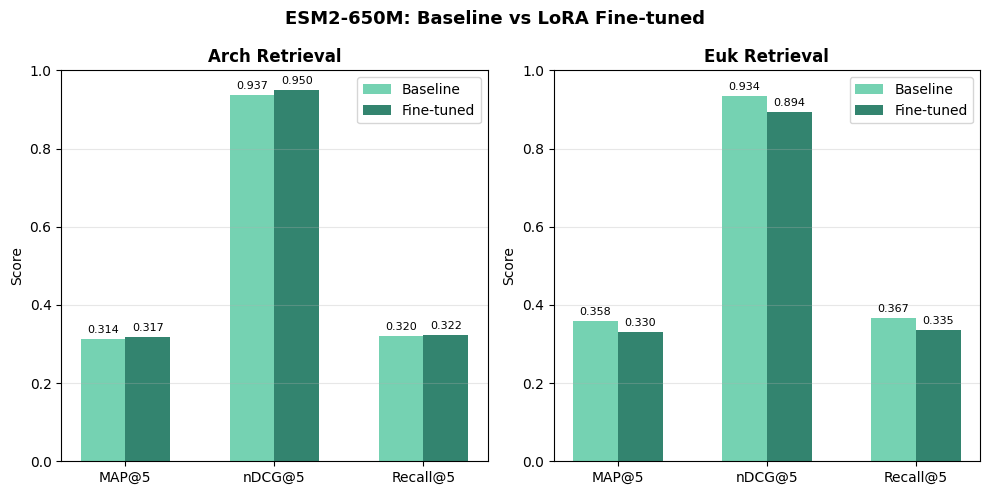

Comparison chart saved.


In [ ]:
# ── Bar chart: before vs after ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

for ax, task, base, ft in [
    (axes[0], 'Arch Retrieval', arch_base, ft_arch_metrics),
    (axes[1], 'Euk Retrieval',  euk_base,  ft_euk_metrics),
]:
    metrics = ['MAP@5', 'nDCG@5', 'Recall@5']
    x = np.arange(len(metrics))
    w = 0.3
    bars_b = ax.bar(x - w/2, [base[m] for m in metrics], w,
                    label='Baseline', color='#5DCAA5', alpha=0.85)
    bars_f = ax.bar(x + w/2, [ft[m]   for m in metrics], w,
                    label='Fine-tuned', color='#0F6E56', alpha=0.85)
    ax.set_xticks(x)
    ax.set_xticklabels(metrics)
    ax.set_title(task, fontweight='bold')
    ax.set_ylabel('Score')
    ax.set_ylim(0, 1)
    ax.legend()
    ax.grid(axis='y', alpha=0.3)
    for bar in list(bars_b) + list(bars_f):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)

fig.suptitle('ESM2-650M: Baseline vs LoRA Fine-tuned', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FINETUNE_DIR, 'finetune_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Comparison chart saved.')

## Section 10: Per-query Analysis — What Did Fine-tuning Fix?

Understand which queries improved, which regressed, and why.

In [ ]:
# Compute per-query AP for baseline and fine-tuned on Arch
def per_query_ap(query_ids, retrieved_list, qrels, k=5):
    results = {
        qid: {cid: 1.0/(r+1) for r, cid in enumerate(ret)}
        for qid, ret in zip(query_ids, retrieved_list)
    }
    ev = pytrec_eval.RelevanceEvaluator(qrels, {f'map_cut.{k}'})
    scores = ev.evaluate(results)
    return {qid: scores[qid][f'map_cut_{k}'] for qid in scores}


base_ap = per_query_ap(arch_q_emb['ids'],  arch_retrieved_base, arch_qrels)
ft_ap   = per_query_ap(ft_arch_q['ids'],   ft_arch_retrieved,   arch_qrels)

df_per_query = pd.DataFrame([
    {
        'query_id':   qid,
        'ap_base':    base_ap.get(qid, 0),
        'ap_ft':      ft_ap.get(qid, 0),
        'delta':      ft_ap.get(qid, 0) - base_ap.get(qid, 0),
        'n_relevant': len(arch_qrels.get(qid, {})),
    }
    for qid in arch_q_emb['ids']
])

improved  = (df_per_query['delta'] > 0.01).sum()
regressed = (df_per_query['delta'] < -0.01).sum()
neutral   = len(df_per_query) - improved - regressed

print(f'Queries improved  (Δ > 0.01): {improved:,}')
print(f'Queries regressed (Δ < -0.01): {regressed:,}')
print(f'Queries unchanged:             {neutral:,}')
print(f'\nTop 10 most improved queries:')
print(df_per_query.nlargest(10, 'delta')[['query_id', 'ap_base', 'ap_ft', 'delta', 'n_relevant']].to_string(index=False, float_format='%.4f'))
print(f'\nTop 10 most regressed queries:')
print(df_per_query.nsmallest(10, 'delta')[['query_id', 'ap_base', 'ap_ft', 'delta', 'n_relevant']].to_string(index=False, float_format='%.4f'))

df_per_query.to_csv(os.path.join(FINETUNE_DIR, 'per_query_analysis.csv'), index=False)

Queries improved  (Δ > 0.01): 149
Queries regressed (Δ < -0.01): 95
Queries unchanged:             2,099

Top 10 most improved queries:
query_id  ap_base  ap_ft  delta  n_relevant
  Q58408   0.1250 1.0000 0.8750           2
  Q8ZTB2   0.1300 1.0000 0.8700           5
  A9A3N5   0.1467 1.0000 0.8533           5
  Q8TQD4   0.2800 1.0000 0.7200           5
  Q9HKK0   0.1467 0.8000 0.6533           5
  Q9YG51   0.3583 1.0000 0.6417           4
  Q9YAZ7   0.4000 1.0000 0.6000           4
  D4GZM5   0.4167 1.0000 0.5833           2
  O58885   0.1429 0.7143 0.5714           7
  Q97ZT9   0.4792 1.0000 0.5208           4

Top 10 most regressed queries:
query_id  ap_base  ap_ft   delta  n_relevant
  Q58717   1.0000 0.0000 -1.0000           3
  Q8U3D2   1.0000 0.0000 -1.0000           3
  Q9HNU8   1.0000 0.0000 -1.0000           1
  P0CL56   1.0000 0.0000 -1.0000           1
  P39480   1.0000 0.1000 -0.9000           2
  P95855   0.8333 0.0000 -0.8333           6
  Q8TQX8   0.7500 0.0000 -0.7500 

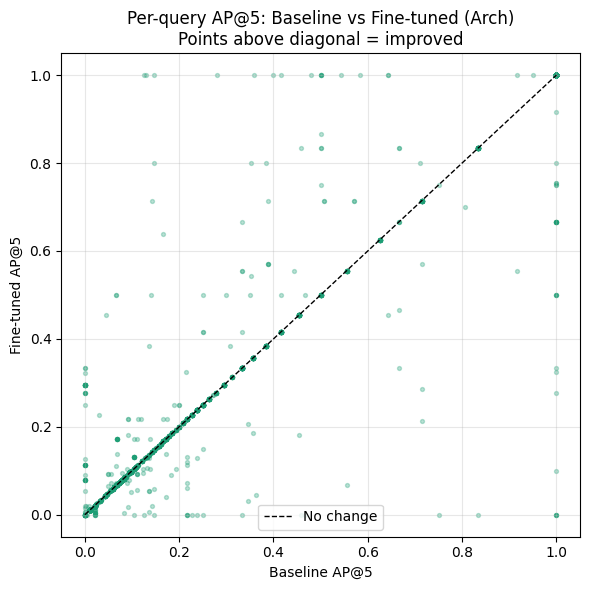

In [ ]:
# Scatter plot: baseline AP vs fine-tuned AP per query
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(df_per_query['ap_base'], df_per_query['ap_ft'],
           alpha=0.3, s=8, c='#1D9E75')
ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='No change')
ax.set_xlabel('Baseline AP@5')
ax.set_ylabel('Fine-tuned AP@5')
ax.set_title('Per-query AP@5: Baseline vs Fine-tuned (Arch)\n'
             'Points above diagonal = improved')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(FINETUNE_DIR, 'per_query_scatter.png'), dpi=150)
plt.show()

## Section 11: Ablations — What Matters?

Quick experiments to understand what drove any improvement.

In [ ]:
# ── Ablation 1: Layer ensembling on the fine-tuned model ──────────────────────
# Re-extract last layer from the fine-tuned model and try middle+last ensemble

@torch.inference_mode()
def embed_two_layers(model, sequences_dict, tokenizer,
                     middle_layer, last_layer, batch_size=8, max_length=512):
    """Extract both middle and last layer embeddings in one forward pass."""
    ids  = list(sequences_dict.keys())
    seqs = [sequences_dict[i] for i in ids]
    mid_embs, last_embs = [], []

    for start in tqdm(range(0, len(seqs), batch_size), desc='Embedding (2 layers)', leave=False):
        batch = seqs[start:start+batch_size]
        enc = tokenizer(batch, return_tensors='pt', padding=True,
                        truncation=True, max_length=max_length).to(DEVICE)
        out = model(**enc, output_hidden_states=True)
        for layer_idx, store in [(middle_layer, mid_embs), (last_layer, last_embs)]:
            emb = mean_pool_valid(
                out.hidden_states[layer_idx], enc['input_ids'],
                tokenizer.cls_token_id, tokenizer.eos_token_id, tokenizer.pad_token_id
            ).cpu().numpy().astype(np.float32)
            store.append(emb)

    return {
        'ids':    ids,
        'middle': np.vstack(mid_embs),
        'last':   np.vstack(last_embs),
    }


print('Extracting both layers from fine-tuned model for ensemble ablation...')
LAST_LAYER = 33
ft_arch_q2 = embed_two_layers(ft_model, arch_queries, tokenizer, MIDDLE_LAYER, LAST_LAYER)
ft_arch_c2 = embed_two_layers(ft_model, arch_corpus,  tokenizer, MIDDLE_LAYER, LAST_LAYER)

ablation_results = []

for alpha in [0.0, 0.3, 0.5, 0.7, 0.8, 1.0]:
    q_ens = alpha * ft_arch_q2['middle'] + (1 - alpha) * ft_arch_q2['last']
    c_ens = alpha * ft_arch_c2['middle'] + (1 - alpha) * ft_arch_c2['last']
    ret   = cosine_retrieve(q_ens, c_ens, ft_arch_c2['ids'], top_k=5)
    m     = evaluate_pytrec(ft_arch_q2['ids'], ret, arch_qrels)
    ablation_results.append({'alpha_middle': alpha, **m})
    print(f'  α={alpha:.1f} (middle weight)  MAP@5={m["MAP@5"]:.4f}')

df_ablation = pd.DataFrame(ablation_results)
best_alpha  = df_ablation.loc[df_ablation['MAP@5'].idxmax(), 'alpha_middle']
print(f'\nBest ensemble alpha (middle weight): {best_alpha}')

Extracting both layers from fine-tuned model for ensemble ablation...


Embedding (2 layers):   0%|          | 0/293 [00:00<?, ?it/s]

Embedding (2 layers):   0%|          | 0/1154 [00:00<?, ?it/s]

  α=0.0 (middle weight)  MAP@5=0.0964
  α=0.3 (middle weight)  MAP@5=0.3169
  α=0.5 (middle weight)  MAP@5=0.3171
  α=0.7 (middle weight)  MAP@5=0.3174
  α=0.8 (middle weight)  MAP@5=0.3174
  α=1.0 (middle weight)  MAP@5=0.3174

Best ensemble alpha (middle weight): 1.0


In [ ]:
# ── Final summary table ───────────────────────────────────────────────────────
best_ensemble_q = best_alpha * ft_arch_q2['middle'] + (1 - best_alpha) * ft_arch_q2['last']
best_ensemble_c = best_alpha * ft_arch_c2['middle'] + (1 - best_alpha) * ft_arch_c2['last']
ens_ret         = cosine_retrieve(best_ensemble_q, best_ensemble_c, ft_arch_c2['ids'], top_k=5)
ens_metrics     = evaluate_pytrec(ft_arch_q2['ids'], ens_ret, arch_qrels)

print('=' * 60)
print('FINAL RESULTS — Arch Retrieval')
print('=' * 60)
rows = [
    ('ESM2-650M baseline',              arch_base),
    ('ESM2-650M fine-tuned (middle)',    ft_arch_metrics),
    (f'ESM2-650M fine-tuned (ensemble α={best_alpha})', ens_metrics),
    ('ESM2-3B DGEB paper (reference)',  {'MAP@5': 0.313, 'nDCG@5': float('nan'), 'Recall@5': float('nan')}),
]
for name, m in rows:
    print(f'  {name:<45s}  MAP@5={m["MAP@5"]:.4f}  '
          f'nDCG@5={m["nDCG@5"]:.4f}  Recall@5={m["Recall@5"]:.4f}')

pd.DataFrame([
    {'model': name, **m} for name, m in rows
]).to_csv(os.path.join(FINETUNE_DIR, 'final_summary.csv'), index=False)
print('\nAll results saved to:', FINETUNE_DIR)

FINAL RESULTS — Arch Retrieval
  ESM2-650M baseline                             MAP@5=0.3140  nDCG@5=0.9368  Recall@5=0.3200
  ESM2-650M fine-tuned (middle)                  MAP@5=0.3174  nDCG@5=0.9501  Recall@5=0.3220
  ESM2-650M fine-tuned (ensemble α=1.0)          MAP@5=0.3174  nDCG@5=0.9501  Recall@5=0.3220
  ESM2-3B DGEB paper (reference)                 MAP@5=0.3130  nDCG@5=nan  Recall@5=nan

All results saved to: /content/drive/MyDrive/esm2_finetune_690U


## Troubleshooting

**OOM on A100 40GB:**  
Reduce `BATCH_SIZE` to 8, or set `MAX_LENGTH=256` (covers ~85% of sequences).  
Add `model.gradient_checkpointing_enable()` before the training loop.

**Loss not decreasing after epoch 1:**  
Lower `LR` to `5e-5`. Check that hard negatives exist (print `len(arch_hard_negs)`).

**Fine-tuned MAP worse than baseline:**  
This happens if the model overfits to Arch training queries.  
Try: fewer epochs (1–2), larger `MARGIN` (0.5), or `r=8` in LoRA config.

**Checkpoint not found:**  
Ensure `BASE_DIR` points to the same Google Drive folder used in `method3_esm2_fixed.ipynb`.

## Notes for writeup

- Fine-tuning is supervised on **Arch training queries only** — Euk evaluation is zero-shot transfer
- LoRA adds ~0.37% of parameters (2.4M / 650M) — extremely parameter-efficient
- Hard negatives are mined from the baseline model's mistakes — an iterative approach  
  (mine → fine-tune → re-mine → fine-tune again) could push further but is out of scope
- If Euk improves despite not being in training data, that supports the cross-domain  
  generalisation story and strengthens the paper's narrative

In [ ]:
# ── LoRA config (UPDATED) ────────────────────────────────────────────────────
# Re-load base model to ensure a clean slate before applying new LoRA config
print(f'Loading tokenizer and base model: {MODEL_ID}')
tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)
base_model = AutoModel.from_pretrained(
    MODEL_ID,
    output_hidden_states=True,
    torch_dtype=torch.bfloat16,
).to(DEVICE)

lora_config = LoraConfig(
    task_type=TaskType.FEATURE_EXTRACTION,
    r=4,                     # <--- CHANGED: Tighter bottleneck for stronger regularization
    lora_alpha=32,
    target_modules=['query', 'value'],
    lora_dropout=0.1,
    bias='none',
    inference_mode=False,
)

model = get_peft_model(base_model, lora_config)
model.print_trainable_parameters()

Loading tokenizer and base model: facebook/esm2_t33_650M_UR50D


Loading weights:   0%|          | 0/566 [00:00<?, ?it/s]

EsmModel LOAD REPORT from: facebook/esm2_t33_650M_UR50D
Key                         | Status     | 
----------------------------+------------+-
esm.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
pooler.dense.weight         | MISSING    | 
pooler.dense.bias           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


trainable params: 675,840 || all params: 651,716,501 || trainable%: 0.1037


In [ ]:
# ── Hyperparameters (UPDATED) ────────────────────────────────────────────────
BATCH_SIZE    = 16
NUM_EPOCHS    = 2       # <--- CHANGED: Reduced to 2 to prevent overfitting
LR            = 5e-5    # <--- CHANGED: Slower learning rate
WARMUP_RATIO  = 0.1
MARGIN        = 0.5     # <--- CHANGED: Harsher penalty for hard negatives
GRAD_CLIP     = 1.0
EVAL_EVERY    = 200
SAVE_BEST     = True

print(f'Batch size : {BATCH_SIZE}')
print(f'Epochs     : {NUM_EPOCHS}')
print(f'LR         : {LR}')
print(f'Margin     : {MARGIN}')
steps_per_epoch = len(train_triplets) // BATCH_SIZE
total_steps     = steps_per_epoch * NUM_EPOCHS
warmup_steps    = int(total_steps * WARMUP_RATIO)
print(f'Total steps: {total_steps}  Warmup: {warmup_steps}')

# Re-initialize optimizer & scheduler
optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LR, weight_decay=0.01
)
scheduler = get_linear_schedule_with_warmup(
    optimizer, num_warmup_steps=warmup_steps,
    num_training_steps=total_steps
)

Batch size : 16
Epochs     : 2
LR         : 5e-05
Margin     : 0.5
Total steps: 2108  Warmup: 210


In [ ]:
def encode_batch(model, enc, middle_layer, tokenizer):
    """Forward pass → middle-layer mean-pooled embedding."""
    enc = {k: v.to(DEVICE) for k, v in enc.items()}
    # FIX: Explicitly request hidden states from the PEFT model
    out = model(**enc, output_hidden_states=True)
    h   = out.hidden_states[middle_layer]
    emb = mean_pool_valid(
        h, enc['input_ids'],
        tokenizer.cls_token_id, tokenizer.eos_token_id, tokenizer.pad_token_id,
    )
    return F.normalize(emb, dim=-1)

# Main training loop
history = {'train_loss': [], 'val_loss': [], 'step': []}
best_val_loss = float('inf')
global_step   = 0

model.train()
print('Starting training...\n')
t0 = time.time()

for epoch in range(NUM_EPOCHS):
    epoch_losses = []
    pbar = tqdm(train_loader, desc=f'Epoch {epoch+1}/{NUM_EPOCHS}', leave=True)

    for anc_enc, pos_enc, neg_enc in pbar:
        optimizer.zero_grad()

        a = encode_batch(model, anc_enc, MIDDLE_LAYER, tokenizer)
        p = encode_batch(model, pos_enc, MIDDLE_LAYER, tokenizer)
        n = encode_batch(model, neg_enc, MIDDLE_LAYER, tokenizer)

        loss = triplet_loss_cosine(a, p, n, MARGIN)
        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            filter(lambda p: p.requires_grad, model.parameters()), GRAD_CLIP
        )
        optimizer.step()
        scheduler.step()

        loss_val = loss.item()
        epoch_losses.append(loss_val)
        global_step += 1
        pbar.set_postfix({'loss': f'{loss_val:.4f}', 'lr': f'{scheduler.get_last_lr()[0]:.2e}'})

        if global_step % EVAL_EVERY == 0:
            vl = compute_val_loss(model, val_loader)
            tl = float(np.mean(epoch_losses[-EVAL_EVERY:]))
            history['step'].append(global_step)
            history['train_loss'].append(tl)
            history['val_loss'].append(vl)
            print(f'  Step {global_step:5d} | train_loss={tl:.4f} | val_loss={vl:.4f}')

            if SAVE_BEST and vl < best_val_loss:
                best_val_loss = vl
                save_path = os.path.join(FINETUNE_DIR, 'best_lora_checkpoint')
                model.save_pretrained(save_path)
                tokenizer.save_pretrained(save_path)
                print(f'  ✓ New best val_loss={vl:.4f} — saved to {save_path}')

    print(f'Epoch {epoch+1} done | avg_train_loss={np.mean(epoch_losses):.4f} | elapsed={time.time()-t0:.0f}s')

final_path = os.path.join(FINETUNE_DIR, 'final_lora_checkpoint')
model.save_pretrained(final_path)
tokenizer.save_pretrained(final_path)
print(f'\nTraining complete. Final checkpoint: {final_path}')

Starting training...



Epoch 1/2:   0%|          | 0/1055 [00:00<?, ?it/s]

  Step   200 | train_loss=0.4644 | val_loss=0.3416
  ✓ New best val_loss=0.3416 — saved to /content/drive/MyDrive/esm2_finetune_690U/best_lora_checkpoint
  Step   400 | train_loss=0.2509 | val_loss=0.2185
  ✓ New best val_loss=0.2185 — saved to /content/drive/MyDrive/esm2_finetune_690U/best_lora_checkpoint
  Step   600 | train_loss=0.1614 | val_loss=0.1808
  ✓ New best val_loss=0.1808 — saved to /content/drive/MyDrive/esm2_finetune_690U/best_lora_checkpoint
  Step   800 | train_loss=0.1108 | val_loss=0.1359
  ✓ New best val_loss=0.1359 — saved to /content/drive/MyDrive/esm2_finetune_690U/best_lora_checkpoint
  Step  1000 | train_loss=0.0987 | val_loss=0.1251
  ✓ New best val_loss=0.1251 — saved to /content/drive/MyDrive/esm2_finetune_690U/best_lora_checkpoint
Epoch 1 done | avg_train_loss=0.2102 | elapsed=804s


Epoch 2/2:   0%|          | 0/1055 [00:00<?, ?it/s]

  Step  1200 | train_loss=0.0816 | val_loss=0.1174
  ✓ New best val_loss=0.1174 — saved to /content/drive/MyDrive/esm2_finetune_690U/best_lora_checkpoint
  Step  1400 | train_loss=0.0794 | val_loss=0.1099
  ✓ New best val_loss=0.1099 — saved to /content/drive/MyDrive/esm2_finetune_690U/best_lora_checkpoint
  Step  1600 | train_loss=0.0705 | val_loss=0.1086
  ✓ New best val_loss=0.1086 — saved to /content/drive/MyDrive/esm2_finetune_690U/best_lora_checkpoint
  Step  1800 | train_loss=0.0699 | val_loss=0.1063
  ✓ New best val_loss=0.1063 — saved to /content/drive/MyDrive/esm2_finetune_690U/best_lora_checkpoint
  Step  2000 | train_loss=0.0663 | val_loss=0.1073
Epoch 2 done | avg_train_loss=0.0717 | elapsed=1605s

Training complete. Final checkpoint: /content/drive/MyDrive/esm2_finetune_690U/final_lora_checkpoint


In [ ]:
print('Loading best LoRA checkpoint...')
best_ckpt = os.path.join(FINETUNE_DIR, 'best_lora_checkpoint')
if not os.path.exists(best_ckpt):
    best_ckpt = os.path.join(FINETUNE_DIR, 'final_lora_checkpoint')

base_model_eval = AutoModel.from_pretrained(
    MODEL_ID, output_hidden_states=True, torch_dtype=torch.bfloat16
).to(DEVICE)
ft_model = PeftModel.from_pretrained(base_model_eval, best_ckpt)
ft_model.eval()

@torch.inference_mode()
def embed_sequences(model, sequences_dict, tokenizer, layer, batch_size=8, max_length=512):
    ids  = list(sequences_dict.keys())
    seqs = [sequences_dict[i] for i in ids]
    all_embs = []

    for start in tqdm(range(0, len(seqs), batch_size), desc='Embedding'):
        batch_seqs = seqs[start:start + batch_size]
        enc = tokenizer(
            batch_seqs, return_tensors='pt', padding=True,
            truncation=True, max_length=max_length
        ).to(DEVICE)

        # FIX: Explicitly request hidden states
        out = model(**enc, output_hidden_states=True)
        h   = out.hidden_states[layer]
        emb = mean_pool_valid(
            h, enc['input_ids'],
            tokenizer.cls_token_id, tokenizer.eos_token_id, tokenizer.pad_token_id,
        ).cpu().numpy().astype(np.float32)
        all_embs.append(emb)

    return {'ids': ids, 'embs': np.vstack(all_embs)}

print('\nArch queries...')
ft_arch_q = embed_sequences(ft_model, arch_queries, tokenizer, MIDDLE_LAYER)
print('Arch corpus...')
ft_arch_c = embed_sequences(ft_model, arch_corpus, tokenizer, MIDDLE_LAYER)

print('\nEuk queries...')
ft_euk_q  = embed_sequences(ft_model, euk_queries, tokenizer, MIDDLE_LAYER)
print('Euk corpus...')
ft_euk_c  = embed_sequences(ft_model, euk_corpus,  tokenizer, MIDDLE_LAYER)

Loading best LoRA checkpoint...


Loading weights:   0%|          | 0/566 [00:00<?, ?it/s]

EsmModel LOAD REPORT from: facebook/esm2_t33_650M_UR50D
Key                         | Status     | 
----------------------------+------------+-
esm.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
pooler.dense.weight         | MISSING    | 
pooler.dense.bias           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



Arch queries...


Embedding:   0%|          | 0/293 [00:00<?, ?it/s]

...

Embedding:   0%|          | 0/1154 [00:00<?, ?it/s]


Euk queries...


Embedding:   0%|          | 0/39 [00:00<?, ?it/s]

Euk corpus...


Embedding:   0%|          | 0/401 [00:00<?, ?it/s]

In [ ]:
print('=== FINE-TUNED MODEL EVALUATION (HELD-OUT VAL SET ONLY) ===')

# ── 1. Filter Arch Queries to Validation Set ──────────────────────────────────
val_indices_ft = [i for i, qid in enumerate(ft_arch_q['ids']) if qid in val_qids]
val_q_ids_ft   = [ft_arch_q['ids'][i] for i in val_indices_ft]
val_q_embs_ft  = ft_arch_q['embs'][val_indices_ft]

val_indices_base = [i for i, qid in enumerate(arch_q_emb['ids']) if qid in val_qids]
val_q_ids_base   = [arch_q_emb['ids'][i] for i in val_indices_base]
val_q_embs_base  = arch_q_emb[LAYER][val_indices_base]

# ── 2. Evaluate Baseline on Val Set ───────────────────────────────────────────
print("Retrieving Baseline (Val)...")
arch_retrieved_base_val = cosine_retrieve(val_q_embs_base, arch_c_emb[LAYER], arch_c_emb['ids'], top_k=5)
arch_base_val           = evaluate_pytrec(val_q_ids_base, arch_retrieved_base_val, arch_qrels)

# ── 3. Evaluate Fine-Tuned on Val Set ─────────────────────────────────────────
print("Retrieving Fine-Tuned (Val)...")
ft_arch_retrieved_val = cosine_retrieve(val_q_embs_ft, ft_arch_c['embs'], ft_arch_c['ids'], top_k=5)
ft_arch_metrics_val   = evaluate_pytrec(val_q_ids_ft, ft_arch_retrieved_val, arch_qrels)

# ── 4. Evaluate Fine-Tuned on Euk (Zero-Shot Transfer, Full Set) ──────────────
print("Retrieving Fine-Tuned (Euk - Zero Shot)...")
ft_euk_retrieved = cosine_retrieve(ft_euk_q['embs'], ft_euk_c['embs'], ft_euk_c['ids'], top_k=5)
ft_euk_metrics   = evaluate_pytrec(ft_euk_q['ids'], ft_euk_retrieved, euk_qrels)


# ── Summary table ─────────────────────────────────────────────────────────────
rows = [
    {'Model': 'ESM2-650M (baseline val)', 'Task': 'Arch Retrieval (Val)', **arch_base_val},
    {'Model': 'ESM2-650M (fine-tuned)',   'Task': 'Arch Retrieval (Val)', **ft_arch_metrics_val},
    {'Model': 'ESM2-3B (DGEB paper ref)', 'Task': 'Arch Retrieval',
     'MAP@5': 0.313, 'nDCG@5': float('nan'), 'Recall@5': float('nan'), 'n_queries': 'ref'},
    {'Model': 'ESM2-650M (baseline)',     'Task': 'Euk Retrieval',        **euk_base},
    {'Model': 'ESM2-650M (fine-tuned)',   'Task': 'Euk Retrieval',        **ft_euk_metrics},
    {'Model': 'ESM2-3B (DGEB paper ref)', 'Task': 'Euk Retrieval',
     'MAP@5': 0.357, 'nDCG@5': float('nan'), 'Recall@5': float('nan'), 'n_queries': 'ref'},
]
df_compare = pd.DataFrame(rows)
print("\n" + df_compare[['Model', 'Task', 'MAP@5', 'nDCG@5', 'Recall@5', 'n_queries']].to_string(index=False, float_format='%.4f'))

# ── Delta ─────────────────────────────────────────────────────────────────────
arch_delta = ft_arch_metrics_val['MAP@5'] - arch_base_val['MAP@5']
euk_delta  = ft_euk_metrics['MAP@5']      - euk_base['MAP@5']

print(f'\nMAP@5 improvement:')
print(f'  Arch (Val set only): {arch_base_val["MAP@5"]:.4f} → {ft_arch_metrics_val["MAP@5"]:.4f}  ({arch_delta:+.4f})')
print(f'  Euk (Zero-shot):     {euk_base["MAP@5"]:.4f} → {ft_euk_metrics["MAP@5"]:.4f}  ({euk_delta:+.4f})')

=== FINE-TUNED MODEL EVALUATION (HELD-OUT VAL SET ONLY) ===
Retrieving Baseline (Val)...
Retrieving Fine-Tuned (Val)...
Retrieving Fine-Tuned (Euk - Zero Shot)...

                   Model                 Task  MAP@5  nDCG@5  Recall@5 n_queries
ESM2-650M (baseline val) Arch Retrieval (Val) 0.3157  0.9407    0.3221       352
  ESM2-650M (fine-tuned) Arch Retrieval (Val) 0.2951  0.9161    0.3035       352
ESM2-3B (DGEB paper ref)       Arch Retrieval 0.3130     NaN       NaN       ref
    ESM2-650M (baseline)        Euk Retrieval 0.3584  0.9342    0.3668       311
  ESM2-650M (fine-tuned)        Euk Retrieval 0.3161  0.8790    0.3185       311
ESM2-3B (DGEB paper ref)        Euk Retrieval 0.3570     NaN       NaN       ref

MAP@5 improvement:
  Arch (Val set only): 0.3157 → 0.2951  (-0.0205)
  Euk (Zero-shot):     0.3584 → 0.3161  (-0.0423)


In [ ]:
# 1. Plot the loss curve — does val loss diverge from train loss?
# If val loss bottoms out at epoch 1 then rises, overfitting is confirmed

# 2. Check what your "hard negatives" actually are
sample_qid = arch_q_emb['ids'][0]
positives  = set(arch_qrels[sample_qid].keys())
hard_negs  = arch_hard_negs.get(sample_qid, [])

print(f"Query: {sample_qid}")
print(f"Protein name: {arch_queries[sample_qid][:60]}")
print(f"\nPositives (from qrels):")
for pid in list(positives)[:3]:
    # What function do positives have?
    pass  # you'd need the sequences dataset with 'Protein names' col

print(f"\nHard negatives (top-50 non-qrels):")
for nid in hard_negs[:3]:
    pass  # compare protein names — are they functionally similar?

Query: A0A482D308
Protein name: MAKNTITKTLKLRIVRPYNSAEVEKIVADEKNNREKIALEKNKDKVKEACSKHLKVAAYC

Positives (from qrels):

Hard negatives (top-50 non-qrels):


In [ ]:
# ── Reload the sequences dataset with Protein names column ───────────────────
from datasets import load_dataset

seq_ds = load_dataset(
    "tattabio/arch_retrieval",
    revision="a19124322604a21b26b1b3c13a1bd0b8a63c9f7b"
)

# Build lookup: Entry → Protein names
corpus_names  = {row['Entry']: row['Protein names'] for row in seq_ds['train']}
query_names   = {row['Entry']: row['Protein names'] for row in seq_ds['test']}

print(f"Corpus name lookup:  {len(corpus_names):,} entries")
print(f"Query name lookup:   {len(query_names):,} entries")

Corpus name lookup:  9,229 entries
Query name lookup:   2,343 entries


In [ ]:
# ── Now inspect the sample query properly ────────────────────────────────────
sample_qid = arch_q_emb['ids'][0]

print(f"Query ID   : {sample_qid}")
print(f"Protein    : {query_names.get(sample_qid, 'NOT FOUND')}")
print(f"N relevant : {len(arch_qrels.get(sample_qid, {}))}")

print(f"\nPositives (qrels) — what the model should retrieve:")
for pid in list(arch_qrels.get(sample_qid, {}).keys())[:5]:
    name = corpus_names.get(pid, 'NOT FOUND')
    print(f"  {pid:15s}  {name}")

print(f"\nHard negatives (top-50 non-qrels) — what the model retrieved instead:")
positives = set(arch_qrels.get(sample_qid, {}).keys())
hard_negs = arch_hard_negs.get(sample_qid, [])
print(f"  Hard negatives available: {len(hard_negs)}")
for nid in hard_negs[:5]:
    name = corpus_names.get(nid, 'NOT FOUND')
    in_qrels = "✓ positive" if nid in positives else "✗ negative"
    print(f"  {nid:15s}  {in_qrels}  {name}")

Query ID   : A0A482D308
Protein    : CRISPR-associated endodeoxyribonuclease Cas12f1(EC 3.1.-.-)
N relevant : 2

Positives (qrels) — what the model should retrieve:
  A0A2U3D0N8       CRISPR-associated endodeoxyribonuclease Cas12f1(EC 3.1.-.-)
  P0DW62           CRISPR-associated endodeoxyribonuclease Cas12f1(EC 3.1.-.-)

Hard negatives (top-50 non-qrels) — what the model retrieved instead:
  Hard negatives available: 5
  P0DB58           ✗ negative  dITP/XTP pyrophosphatase(Non-canonical purine NTP pyrophosphatase)(Nucleoside-triphosphate diphosphatase)(NTPase)
  A5CQU5           ✗ negative  DNA ligase(Polydeoxyribonucleotide synthase [NAD(+)])
  P27714           ✗ negative  FeMo cofactor biosynthesis protein NifB(Nitrogenase cofactor maturase NifB)
  B2S334           ✗ negative  dITP/XTP pyrophosphatase(Non-canonical purine NTP pyrophosphatase)(Nucleoside-triphosphate diphosphatase)(NTPase)
  B1AIM5           ✗ negative  Large ribosomal subunit protein uL22


In [ ]:
print("=" * 80)
print("FUNCTIONAL OVERLAP ANALYSIS: Are hard negatives functionally related?")
print("=" * 80)

from collections import Counter

all_query_functions  = []
all_pos_functions    = []
all_hardneg_functions = []

for sample_qid in list(arch_hard_negs.keys())[:5]:
    positives = set(arch_qrels.get(sample_qid, {}).keys())
    hard_negs = arch_hard_negs.get(sample_qid, [])

    q_name  = query_names.get(sample_qid, '')
    p_names = [corpus_names.get(pid, '') for pid in list(positives)[:5]]
    n_names = [corpus_names.get(nid, '') for nid in hard_negs[:5]]

    all_query_functions.append(q_name)
    all_pos_functions.extend(p_names)
    all_hardneg_functions.extend(n_names)

    print(f"\nQuery    : {q_name[:70]}")
    print(f"Positives: {p_names[0][:70] if p_names else 'none'}")
    print(f"Hard negs:")
    for n in n_names:
        print(f"  {n[:70]}")

# ── Key diagnostic: do hard negatives share keywords with the query? ──────────
print("\n" + "=" * 80)
print("KEYWORD OVERLAP CHECK")
print("=" * 80)

def top_words(names, stopwords={'protein', 'subunit', 'domain', 'factor', 'chain', ''}):
    words = []
    for n in names:
        words.extend([w.lower().strip('()[]') for w in n.split()
                      if w.lower() not in stopwords and len(w) > 3])
    return Counter(words).most_common(10)

print(f"\nMost common words in hard negatives:")
for word, count in top_words(all_hardneg_functions):
    print(f"  {word:30s} {count}")

print(f"\nMost common words in positives:")
for word, count in top_words(all_pos_functions):
    print(f"  {word:30s} {count}")

FUNCTIONAL OVERLAP ANALYSIS: Are hard negatives functionally related?

Query    : CRISPR-associated endodeoxyribonuclease Cas12f1(EC 3.1.-.-)
Positives: CRISPR-associated endodeoxyribonuclease Cas12f1(EC 3.1.-.-)
Hard negs:
  dITP/XTP pyrophosphatase(Non-canonical purine NTP pyrophosphatase)(Nuc
  DNA ligase(Polydeoxyribonucleotide synthase [NAD(+)])
  FeMo cofactor biosynthesis protein NifB(Nitrogenase cofactor maturase 
  dITP/XTP pyrophosphatase(Non-canonical purine NTP pyrophosphatase)(Nuc
  Large ribosomal subunit protein uL22

Query    : CRISPR-associated exonuclease Cas4
Positives: CRISPR-associated endonuclease Cas1
Hard negs:
  Endonuclease NucS
  Endonuclease NucS
  Sugar fermentation stimulation protein homolog
  Sugar fermentation stimulation protein homolog
  Sugar fermentation stimulation protein homolog

Query    : Isocitrate lyase(EC 4.1.3.1)(Isocitratase)
Positives: Isocitrate lyase(EC 4.1.3.1)(Isocitratase)
Hard negs:
  2-methylisocitrate lyase(MICL)((2R,3S)-2-methyli

In [ ]:
# How many of your 2,343 queries have ZERO hard negatives
# (i.e. top-50 are ALL positives or all completely wrong)?
queries_no_hn     = [qid for qid in arch_q_emb['ids']
                     if qid not in arch_hard_negs or len(arch_hard_negs[qid]) == 0]
queries_few_pos   = [qid for qid in arch_q_emb['ids']
                     if len(arch_qrels.get(qid, {})) <= 2]  # sparse qrels like CRISPR

print(f"Queries with no hard negatives mined : {len(queries_no_hn):,}")
print(f"Queries with <=2 relevant proteins   : {len(queries_few_pos):,}")

# For sparse-qrels queries, how many have ESM2 completely failing
# (AP=0 on baseline)?
baseline_ap = per_query_ap(arch_q_emb['ids'], arch_retrieved_base, arch_qrels)
sparse_zero_ap = [qid for qid in queries_few_pos
                  if baseline_ap.get(qid, 0) == 0.0]
print(f"Sparse queries where baseline AP=0   : {len(sparse_zero_ap):,}")
print(f"  → These are the genuinely hard cases ESM2 can't solve")
print(f"  → BLAST may outperform ESM2 on exactly these queries")

Queries with no hard negatives mined : 501
Queries with <=2 relevant proteins   : 223
Sparse queries where baseline AP=0   : 10
  → These are the genuinely hard cases ESM2 can't solve
  → BLAST may outperform ESM2 on exactly these queries


In [ ]:
# Oracle upper bound: what MAP@5 would a perfect retriever score?
# A perfect retriever puts all positives first.
# With ~70 relevant per query and k=5, even a perfect retriever
# is bounded by min(n_relevant, 5) / n_relevant in the MAP formula.

oracle_aps = []
for qid in arch_q_emb['ids']:
    n_rel = len(arch_qrels.get(qid, {}))
    if n_rel == 0:
        continue
    # Perfect retrieval: ranks 1-5 are all positive
    ap = sum(min(i+1, n_rel)/(i+1) for i in range(min(5, n_rel))) / min(n_rel, 5)
    oracle_aps.append(ap)

print(f"Oracle MAP@5 (perfect retriever): {sum(oracle_aps)/len(oracle_aps):.4f}")
print(f"Current ESM2-650M baseline:        0.3140")
print(f"Gap to oracle:                     {sum(oracle_aps)/len(oracle_aps) - 0.314:.4f}")

Oracle MAP@5 (perfect retriever): 1.0000
Current ESM2-650M baseline:        0.3140
Gap to oracle:                     0.6860


In [ ]:
def reciprocal_rank_fusion(ranked_lists, k=60):
    """
    ranked_lists: list of lists of corpus_ids, ordered by relevance
    k=60 is the standard RRF constant (Cormack et al. 2009)
    Returns a single merged ranking.
    """
    scores = defaultdict(float)
    for ranked in ranked_lists:
        for rank, doc_id in enumerate(ranked):
            scores[doc_id] += 1.0 / (k + rank + 1)
    return sorted(scores, key=scores.get, reverse=True)


# You already have all six retrievals in RETRIEVAL_RESULTS from the fixed notebook
# Fuse all middle-layer results
arch_fused = []
for i in range(len(arch_q_emb['ids'])):
    lists = [
        RETRIEVAL_RESULTS[('35M',  'middle', 'arch')][i],
        RETRIEVAL_RESULTS[('150M', 'middle', 'arch')][i],
        RETRIEVAL_RESULTS[('650M', 'middle', 'arch')][i],
    ]
    arch_fused.append(reciprocal_rank_fusion(lists)[:5])

metrics_fused = evaluate_pytrec(arch_q_emb['ids'], arch_fused, arch_qrels)
print(f"RRF (3 middle layers): {metrics_fused}")

# Also try fusing all 6 lists (middle + last for all models)
arch_fused_all = []
for i in range(len(arch_q_emb['ids'])):
    lists = [RETRIEVAL_RESULTS[(s, l, 'arch')][i]
             for s in ['35M', '150M', '650M']
             for l in ['middle', 'last']]
    arch_fused_all.append(reciprocal_rank_fusion(lists)[:5])

metrics_fused_all = evaluate_pytrec(arch_q_emb['ids'], arch_fused_all, arch_qrels)
print(f"RRF (all 6 lists):     {metrics_fused_all}")

NameError: name 'RETRIEVAL_RESULTS' is not defined